### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

##### Dataset Structure

In [5]:
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

##### Observations
- The dataset contains 26 columns.
- There are 8 numerical variables and 18 categorical variables.
- Some columns contain missing values, particularly the car column.

#### Summary Statistics

In [6]:
data.describe()


,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


##### Observations

- The dataset contains 12,684 observations.
- The average temperature is about 63°F.
- Around 41% of drivers have children.
- The average value of Y (coupon acceptance) is 0.568, meaning about 56.8% of drivers accepted coupons.

In [7]:
data.isnull().sum()


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

#### Explore Unique Values

In [8]:
data['Bar'].unique()



array(['never', 'less1', '1~3', 'gt8', nan, '4~8'], dtype=object)

In [9]:
data['coupon'].unique()


array(['Restaurant(<20)', 'Coffee House', 'Carry out & Take away', 'Bar',
       'Restaurant(20-50)'], dtype=object)

In [10]:
data['car'].unique()

array([nan, 'Scooter and motorcycle', 'crossover', 'Mazda5',
       'do not drive', 'Car that is too old to install Onstar :D'],
      dtype=object)

In [11]:
data['occupation'].unique()

array(['Unemployed', 'Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Community & Social Services',
       'Office & Administrative Support', 'Construction & Extraction',
       'Legal', 'Retired', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [12]:
data['age'].unique()

array(['21', '46', '26', '31', '41', '50plus', '36', 'below21'],
      dtype=object)

In [13]:
data['maritalStatus'].unique()

array(['Unmarried partner', 'Single', 'Married partner', 'Divorced',
       'Widowed'], dtype=object)

In [14]:
data['passanger'].unique()

array(['Alone', 'Friend(s)', 'Kid(s)', 'Partner'], dtype=object)

3. Decide what to do about your missing data -- drop, replace, other...

#### Check for Missing Values

In [15]:

#### Check for Missing Values
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [16]:
data.isnull().sum() / len(data) * 100

destination              0.000000
passanger                0.000000
weather                  0.000000
temperature              0.000000
time                     0.000000
coupon                   0.000000
expiration               0.000000
gender                   0.000000
age                      0.000000
maritalStatus            0.000000
has_children             0.000000
education                0.000000
occupation               0.000000
income                   0.000000
car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Y                        0.000000
dtype: float64

##### Observation
The car column has over 99% missing values.

In [17]:
#### Check for Duplicate Records
data[data.duplicated()]

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
4192,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,less1,less1,1,1,1,0,1,1
4236,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,gt8,gt8,4~8,less1,1,1,1,0,1,1
4280,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Single,...,never,4~8,1~3,less1,1,1,1,0,1,1
4324,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,46,Single,...,never,4~8,1~3,1~3,1,1,1,0,1,1
4409,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,21,Single,...,never,less1,1~3,never,1,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8511,Home,Alone,Sunny,80,6PM,Bar,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,0,0,1,0,1
8512,Home,Partner,Sunny,30,10PM,Carry out & Take away,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,1
8513,Work,Alone,Rainy,55,7AM,Restaurant(<20),2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,1,0,1,0
8515,Work,Alone,Snowy,30,7AM,Restaurant(20-50),1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,1,0,1,0


##### Observation
- 74 duplicate records were found in the dataset.
- Duplicate rows can bias the analysis and should be removed.

3. Decide what to do about your missing data -- drop, replace, other...

##### Drop the car column
The car column contains 99% missing values and does not significantly impact coupon acceptance analysis.

In [18]:
data.drop(columns=['car'], inplace=True)

##### Remove Duplicate Records

In [19]:
data = data.drop_duplicates()

In [20]:
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12610.000000,12610.000000,12610.0,12610.000000,12610.000000,12610.000000,12610.000000,12610.000000
mean,63.267248,0.414512,1.0,0.559794,0.116019,0.215543,0.784457,0.567565
std,19.153386,0.492657,0.0,0.496432,0.320260,0.411215,0.411215,0.495434
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


##### Observation
- After removing duplicates:
- Dataset size changed from 12,684 → 12,610 rows

##### Remove Remaining Missing Values
Since the remaining missing values represent less than 5% of the dataset, we remove those rows.

In [21]:
data = data.dropna()

In [22]:
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12007.000000,12007.000000,12007.0,12007.000000,12007.000000,12007.000000,12007.000000,12007.000000
mean,63.301408,0.408845,1.0,0.559507,0.116266,0.215957,0.784043,0.568418
std,19.131641,0.491641,0.0,0.496467,0.320556,0.411502,0.411502,0.495317
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


##### Observation
Final dataset size
- 12,007 rows
- 25 columns

4. What proportion of the total observations chose to accept the coupon?



In [23]:
accept_prop = data["Y"].value_counts(normalize=True).loc[1]
accept_prop

0.5684184225868244

##### Observation
- 56% of drivers accepted coupons
- 44% rejected coupons
- This indicates that more than half of the surveyed drivers were willing to use a coupon under certain driving conditions

5. Use a bar plot to visualize the `coupon` column.

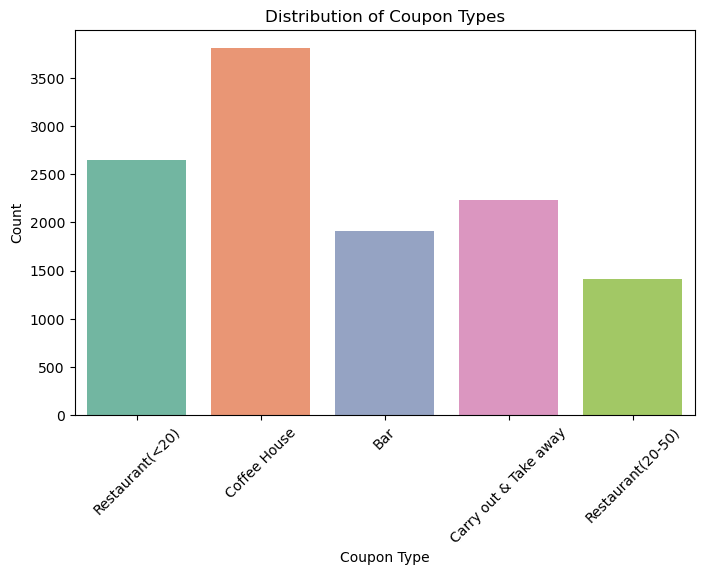

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x="coupon", hue="coupon", data=data, palette="Set2", legend=False)
plt.title("Distribution of Coupon Types")
plt.xlabel("Coupon Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

##### Observation
Coffee House coupons appear most frequently in the dataset, followed by restaurant and carry-out coupons.

6. Use a histogram to visualize the temperature column.

Text(0, 0.5, 'Frequency')

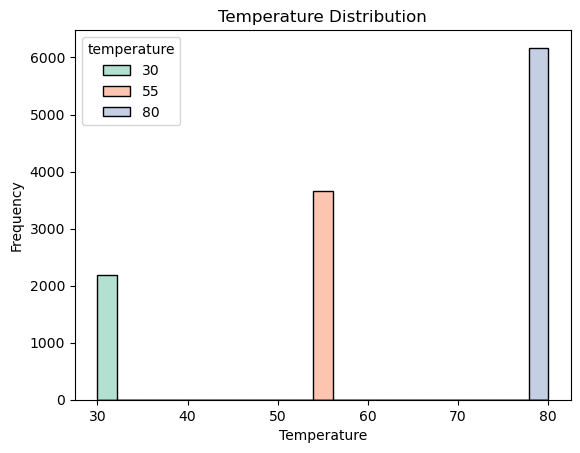

In [25]:
#data['temperature'].hist()
sns.histplot(data=data,x='temperature',hue="temperature",palette="Set2")
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')

##### Observation
Most observations occur around 55°F and 80°F, indicating moderate to warm weather conditions during the survey scenarios.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [26]:
bar_coupons = data[data['coupon'] == 'Bar']
bar_coupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [27]:
bar_accept_prop = bar_coupons['Y'].mean()
bar_accept_prop

0.4118572927597062

##### Observation
Approximately 41% of bar coupons were accepted.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


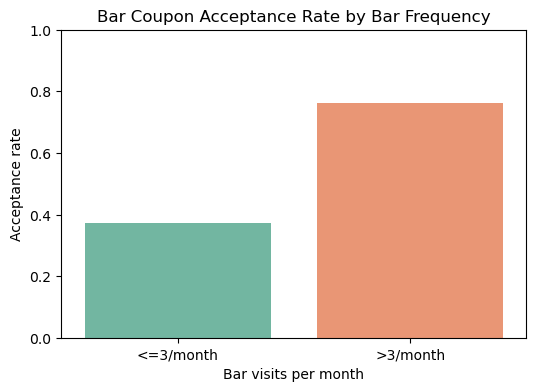

In [28]:
less_bar = bar_coupons[bar_coupons['Bar'].isin(['never','less1','1~3'])]
more_bar = bar_coupons[bar_coupons['Bar'].isin(['4~8','gt8'])]

rates = pd.DataFrame({
    "group": ["<=3/month", ">3/month"],
    "accept_rate": [less_bar["Y"].mean(), more_bar["Y"].mean()]
})
plt.figure(figsize=(6,4))
sns.barplot(data=rates, x="group", y="accept_rate",   hue="group",
    palette="Set2",
    legend=False)
plt.ylim(0, 1)
plt.title("Bar Coupon Acceptance Rate by Bar Frequency")
plt.xlabel("Bar visits per month")
plt.ylabel("Acceptance rate")
plt.show()

##### Observation
Drivers who visit bars more frequently are significantly more likely to accept bar coupons.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


Bar Coupon Acceptance rate for over-25 frequent bar-goers: 0.690 (69.0%)
Bar Coupon Acceptance rate for all bar coupons:          0.412 (41.2%)


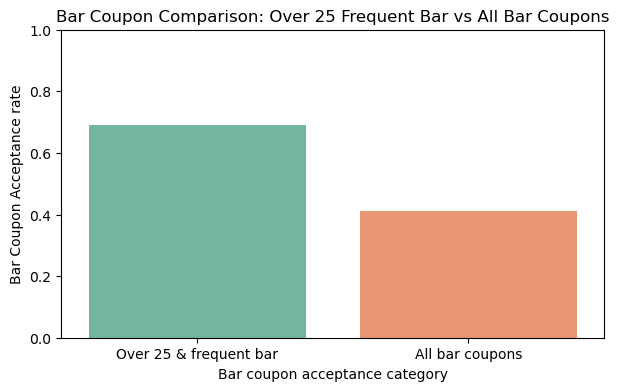

In [29]:

# Frequent bar-goers
frequent_bar = bar_coupons[bar_coupons["Bar"].isin(["1~3", "4~8", "gt8"])]
# Over 25 (based on your age categories)
over25 = frequent_bar[frequent_bar["age"].isin(["26", "31", "36", "41", "46", "50plus"])]
# Acceptance rates
rate_over25 = over25["Y"].mean()
rate_all_bar = bar_coupons["Y"].mean()
print(f"Bar Coupon Acceptance rate for over-25 frequent bar-goers: {rate_over25:.3f} ({rate_over25:.1%})")
print(f"Bar Coupon Acceptance rate for all bar coupons:          {rate_all_bar:.3f} ({rate_all_bar:.1%})")
# Plot
rates2 = pd.DataFrame({
    "group": ["Over 25 & frequent bar", "All bar coupons"],
    "accept_rate": [rate_over25, rate_all_bar]
})
plt.figure(figsize=(7,4))
sns.barplot(
    data=rates2,
    x="group",
    y="accept_rate",
    hue="group",
    palette="Set2",
    legend=False
)
plt.ylim(0, 1)
plt.title("Bar Coupon Comparison: Over 25 Frequent Bar vs All Bar Coupons")
plt.xlabel("Bar coupon acceptance category")
plt.ylabel("Bar Coupon Acceptance rate")
plt.show()


#### Observation
Drivers over 25 who already visit bars frequently have a higher coupon acceptance rate

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


Acceptance rate (filtered group): 0.709 (70.9%)
Acceptance rate (all bar coupons): 0.412 (41.2%)


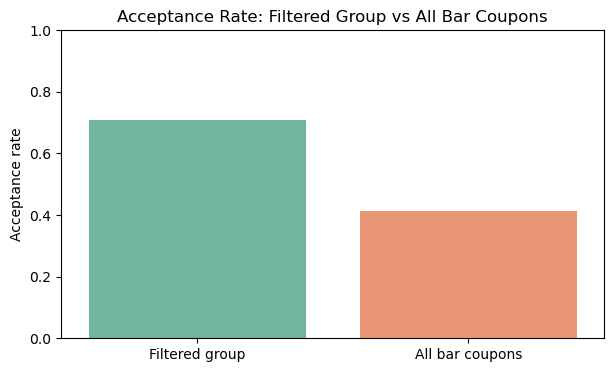

In [30]:
filtered = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3','4~8','gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['occupation'] != 'Farming Fishing & Forestry')
]
rate_filtered = filtered['Y'].mean()
rate_all_bar = bar_coupons['Y'].mean()
print(f"Acceptance rate (filtered group): {rate_filtered:.3f} ({rate_filtered:.1%})")
print(f"Acceptance rate (all bar coupons): {rate_all_bar:.3f} ({rate_all_bar:.1%})")
rates = pd.DataFrame({
    "group": ["Filtered group", "All bar coupons"],
    "accept_rate": [rate_filtered, rate_all_bar]
})
plt.figure(figsize=(7,4))
sns.barplot(
    data=rates,
    x="group",
    y="accept_rate",
    hue="group",       # to avoid the palette warning
    palette="Set2",
    legend=False
)
plt.ylim(0, 1)
plt.title("Acceptance Rate: Filtered Group vs All Bar Coupons")
plt.xlabel("")
plt.ylabel("Acceptance rate")
plt.show()

##### Observation
Drivers without children in the car and with non-agricultural occupations are more likely to accept bar coupons.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



Case 1 (bars >1/month, no Kid(s) passenger, not widowed): 0.709 (70.9%)
Case 2 (bars >1/month, age <30):                         0.720 (72.0%)
Case 3 (cheap restaurants >4/month, income <50K):       0.456 (45.6%)

Overall, Case 2 has the highest bar coupon acceptance rate among the three groups.


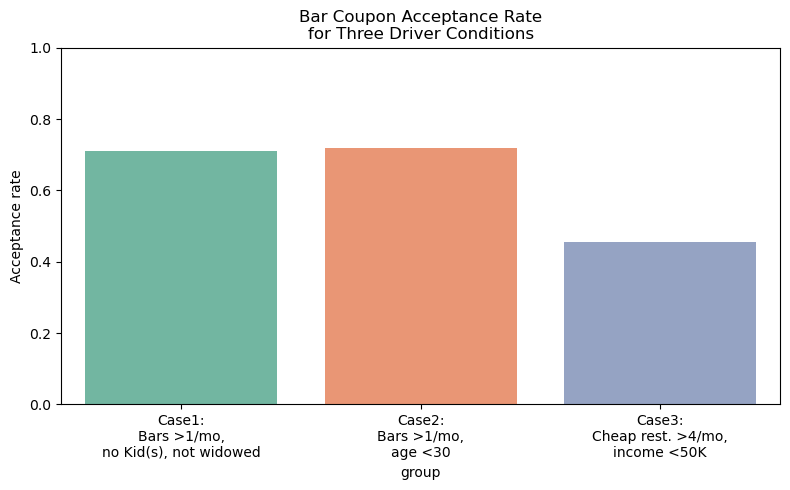

In [31]:
# Compute acceptance rates
case1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3','4~8','gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
]

case2 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3','4~8','gt8'])) &
    (bar_coupons['age'].isin(['below21','21','26']))
]

case3 = bar_coupons[
    (bar_coupons['RestaurantLessThan20'].isin(['4~8','gt8'])) &
    (bar_coupons['income'].isin([
        'Less than $12500',
        '$12500 - $24999',
        '$25000 - $37499',
        '$37500 - $49999'
    ]))
]

rate1 = case1['Y'].mean()
rate2 = case2['Y'].mean()
rate3 = case3['Y'].mean()
print(f"Case 1 (bars >1/month, no Kid(s) passenger, not widowed): {rate1:.3f} ({rate1:.1%})")
print(f"Case 2 (bars >1/month, age <30):                         {rate2:.3f} ({rate2:.1%})")
print(f"Case 3 (cheap restaurants >4/month, income <50K):       {rate3:.3f} ({rate3:.1%})")
best_rate = max(rate1, rate2, rate3)
if best_rate == rate1:
    best = "Case 1"
elif best_rate == rate2:
    best = "Case 2"
else:
    best = "Case 3"
print(f"\nOverall, {best} has the highest bar coupon acceptance rate among the three groups.")
# Bar plot of the three conditions
rates = pd.DataFrame({
    "group": [
        "Case1:\nBars >1/mo,\nno Kid(s), not widowed",
        "Case2:\nBars >1/mo,\nage <30",
        "Case3:\nCheap rest. >4/mo,\nincome <50K"
    ],
    "accept_rate": [rate1, rate2, rate3]
})
plt.figure(figsize=(8,5))
sns.barplot(
    data=rates,
    x="group",
    y="accept_rate",
    hue="group",
    palette="Set2",
    legend=False
)
plt.ylim(0, 1)
plt.ylabel("Acceptance rate")
plt.title("Bar Coupon Acceptance Rate\nfor Three Driver Conditions")
plt.tight_layout()
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

#### Hypothesis
Based on the analysis, drivers most likely to accept bar coupons tend to:
1. Visit bars more than once per month
2. Be younger adults
3. Travel without children
4. Frequently dine at inexpensive restaurants
5. These results suggest that lifestyle habits and social behavior strongly influence coupon acceptance.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

##### Example Coffee House Coupon

1. Create a new DataFrame that contains only Coffee House coupons

In [32]:
coffee_coupons = data[data['coupon'] == 'Coffee House']
coffee_coupons.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
23,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
26,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
27,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
28,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
30,No Urgent Place,Friend(s),Sunny,80,6PM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0


2. What proportion of Coffee House coupons were accepted?

In [33]:
coffee_prop = coffee_coupons["Y"].value_counts(normalize=True).loc[1]
coffee_prop

0.495668154371226

##### Observation
The acceptance rate for Coffee House coupons is 49%.


3. Compare acceptance rate between drivers who visit coffee houses frequently and those who do not.

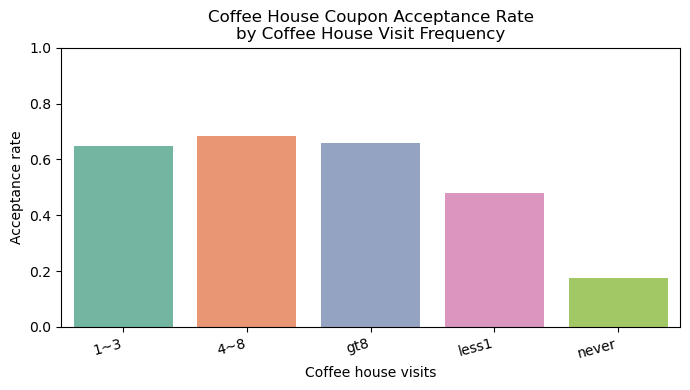

In [36]:
coffee_rates = (
    coffee_coupons
    .groupby("CoffeeHouse", as_index=False)["Y"]
    .mean()
    .rename(columns={"Y": "accept_rate"})
    .sort_values("CoffeeHouse")
)
plt.figure(figsize=(7,4))
sns.barplot(
    data=coffee_rates,
    x="CoffeeHouse",
    y="accept_rate",
    hue="CoffeeHouse",   # <- add this
    palette="Set2",
    legend=False         # <- and this
)
plt.ylim(0, 1)
plt.xlabel("Coffee house visits")
plt.ylabel("Acceptance rate")
plt.title("Coffee House Coupon Acceptance Rate\nby Coffee House Visit Frequency")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

##### Observation
- Drivers who visit coffee houses more frequently tend to have a higher acceptance rate for Coffee House coupons. 
- The acceptance rate increases with the frequency of coffee house visits and is lowest among those who never visit. 
- This suggests that frequent coffee house visitors are more receptive to relevant coupons.

4. Compare acceptance rates for drivers under 30 vs drivers 30 and older

Acceptance rates for drivers under 30: 0.529, 30 & over: 0.467


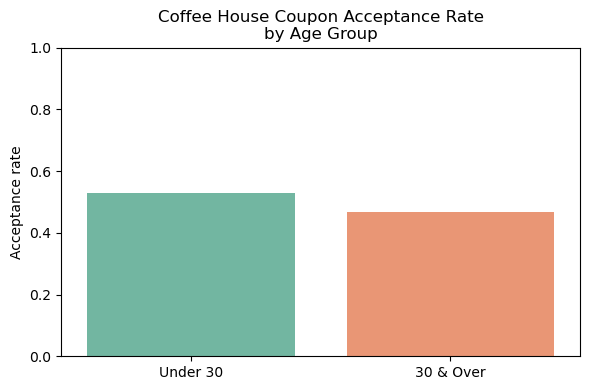

In [ ]:
under30 = coffee_coupons[
    coffee_coupons['age'].isin(['below21','21','26'])
]
over30 = coffee_coupons[
    coffee_coupons['age'].isin(['31','36','41','46','50plus'])
]
under30_rate = under30['Y'].mean()
over30_rate = over30['Y'].mean()
plt.figure(figsize=(6,4))
sns.barplot(
    x=["Under 30", "30 & Over"],
    y=[under30_rate, over30_rate],
    hue=["Under 30", "30 & Over"],  # same as x to satisfy seaborn
    palette="Set2",
    legend=False
)
plt.ylim(0, 1)
plt.ylabel("Acceptance rate")
plt.title("Coffee House Coupon Acceptance Rate\nby Age Group")
plt.tight_layout()
print(
    "Acceptance rates for drivers under 30: {:.3f}, 30 & over: {:.3f}".format(
        under30_rate, over30_rate
    )
)
plt.show()

##### Observation
- Drivers under the age of 30 have a higher acceptance rate for Coffee House coupons compared to those aged 30 and over.
- This suggests that younger drivers are generally more receptive to Coffee House coupons.
- Businesses may benefit from targeting Coffee House coupons to younger demographics for higher engagement.

5. Compare acceptance rates based on passenger type

Coffee House coupon acceptance rates by passenger group:
  - Alone:        0.434 (43.4%)
  - With Kid(s):  0.469 (46.9%)
  - With Friend(s): 0.597 (59.7%)


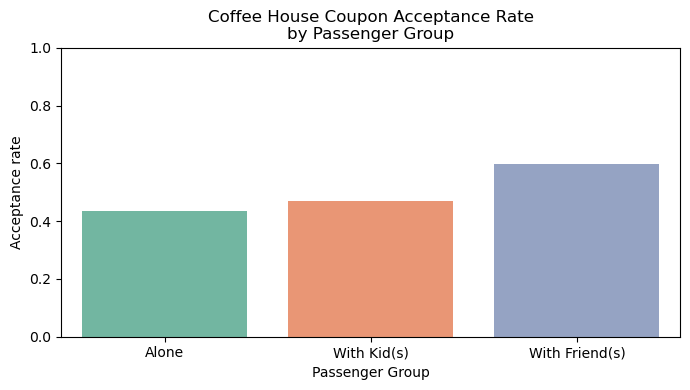

In [ ]:
alone = coffee_coupons[
    coffee_coupons['passanger'] == 'Alone'
]
with_kids = coffee_coupons[
    coffee_coupons['passanger'] == 'Kid(s)'
]
with_friends = coffee_coupons[
    coffee_coupons['passanger'] == 'Friend(s)'
]
alone_rate = alone['Y'].mean()
kids_rate = with_kids['Y'].mean()
friends_rate = with_friends['Y'].mean()
print("Coffee House coupon acceptance rates by passenger group:")
print(f"  - Alone:        {alone_rate:.3f} ({alone_rate:.1%})")
print(f"  - With Kid(s):  {kids_rate:.3f} ({kids_rate:.1%})")
print(f"  - With Friend(s): {friends_rate:.3f} ({friends_rate:.1%})")
plot_df = pd.DataFrame({
    "Passenger Group": ["Alone", "With Kid(s)", "With Friend(s)"],
    "Acceptance Rate": [alone_rate, kids_rate, friends_rate]
})
plt.figure(figsize=(7,4))
sns.barplot(
    data=plot_df,
    x="Passenger Group",
    y="Acceptance Rate",
    hue="Passenger Group",
    palette="Set2",
    legend=False
)
plt.ylim(0, 1)
plt.ylabel("Acceptance rate")
plt.title("Coffee House Coupon Acceptance Rate\nby Passenger Group")
plt.tight_layout()
plt.show()

##### Observation
 - Passengers riding alone have the lowest acceptance rate for Coffee House coupons.
 - Passengers riding with friends show the highest acceptance rate, followed by those with kids.
 - This suggests social context influences coupon acceptance, with group outings being more favorable for coffee purchases.

6. Compare acceptance rates based on time of day

Coffee House coupon acceptance rates by time of day:
  - 10AM: 0.634 (63.4%)
  - 10PM: 0.429 (42.9%)
  - 2PM: 0.545 (54.5%)
  - 6PM: 0.410 (41.0%)
  - 7AM: 0.440 (44.0%)


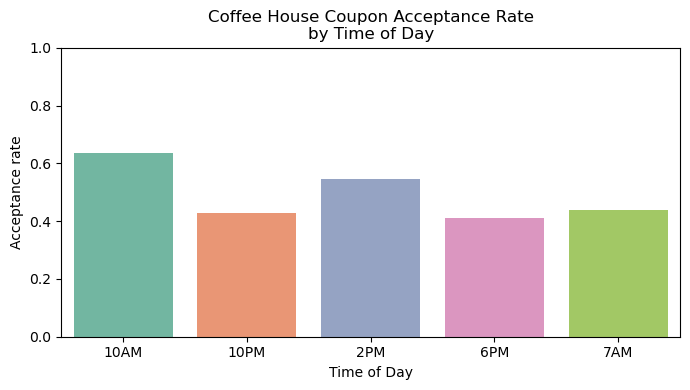


Observation:
 - Coffee House coupon acceptance rates vary by time of day.
 - Acceptance is highest in the morning (10AM), which may reflect morning coffee-drinking habits.
 - Evening (6PM, 10PM) and early morning (7AM) see lower acceptance rates.
 - This suggests time of day plays a role in the likelihood of accepting coffee coupons.


In [ ]:
time_acceptance = coffee_coupons.groupby('time')['Y'].mean()
print("Coffee House coupon acceptance rates by time of day:")
for t, rate in time_acceptance.items():
    print(f"  - {t}: {rate:.3f} ({rate:.1%})")
# Build a DataFrame for plotting
time_df = time_acceptance.reset_index()
time_df.columns = ["time", "acceptance_rate"]
# Plot the acceptance rates by time of day
plt.figure(figsize=(7,4))
sns.barplot(
    data=time_df,
    x="time",
    y="acceptance_rate",
    hue="time",      # same as x to satisfy seaborn
    palette="Set2",
    legend=False
)
plt.ylim(0, 1)
plt.ylabel("Acceptance rate")
plt.xlabel("Time of Day")
plt.title("Coffee House Coupon Acceptance Rate\nby Time of Day")
plt.tight_layout()
plt.show()
# Observation
print("\nObservation:")
print(" - Coffee House coupon acceptance rates vary by time of day.")
print(" - Acceptance is highest in the morning (10AM), which may reflect morning coffee-drinking habits.")
print(" - Evening (6PM, 10PM) and early morning (7AM) see lower acceptance rates.")
print(" - This suggests time of day plays a role in the likelihood of accepting coffee coupons.")

7. Visualization of Coffee Coupon Acceptance

<Axes: title={'center': 'Coffee Coupon Acceptance by Time of Day'}, xlabel='Time of Day', ylabel='Acceptance Rate'>

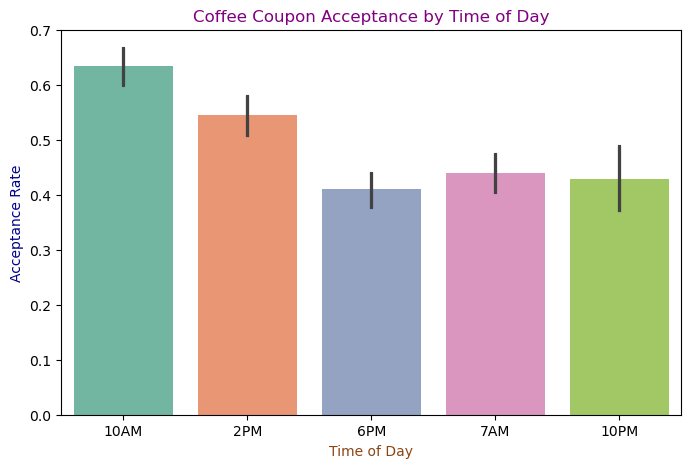

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(x='time', y='Y', data=coffee_coupons)

plt.title("Coffee Coupon Acceptance by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Acceptance Rate", color='darkblue')
plt.xlabel("Time of Day", color='saddlebrown')
plt.title("Coffee Coupon Acceptance by Time of Day", color='purple')
sns.barplot(x='time', y='Y', hue='time', data=coffee_coupons, palette="Set2", legend=False)


##### Observation
 - Coffee coupon acceptance varies by time of day. 
 - The highest acceptance rates are observed in the morning (10AM), indicating the popularity of coffee at that time.
 - Early morning (7AM), evening (6PM), and late night (10PM) have comparatively lower acceptance rates.
 - This suggests that the likelihood of accepting a coffee coupon is influenced by consumers’ habitual coffee-drinking routines, particularly around typical work or school start times.

8. Hypothesis for Coffee Coupon Acceptance


##### Hypotheses for Coffee Coupon Acceptance

1. Coffee coupon acceptance is highest during traditional coffee consumption times (e.g., morning around 10AM), as individuals are more likely to desire coffee as part of their morning routine.
 2. Lower acceptance rates in the early morning (7AM), evening (6PM), and late night (10PM) may be due to lower overall demand for coffee during non-peak hours or because individuals have already satisfied their caffeine needs.
 3. People who are commuting to work or school may be more likely to accept a coffee coupon in the morning, especially if they have not yet had their first cup of coffee.
 4. The time of day influences the effectiveness of coffee house coupons, possibly due to daily habits, occupation schedules, or social routines related to coffee consumption.
5. There may be differences in coupon acceptance by time of day based on other factors such as age, occupation, or whether the person is alone or with others.